In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    "year": [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    "km_driven": [80000, 70000, 60000, 50000, 45000, 35000, 30000, 22000, 15000, 10000],
    "engine": [1200, 1200, 1500, 1500, 1600, 1600, 1800, 1800, 2000, 2000],
    "price": [4.5, 5.2, 6.5, 7.2, 8.5, 10.0, 12.0, 14.0, 17.0, 19.0]
}

df = pd.DataFrame(data)

df

,year,km_driven,engine,price
0,2015,80000,1200,4.5
1,2016,70000,1200,5.2
2,2017,60000,1500,6.5
3,2018,50000,1500,7.2
4,2019,45000,1600,8.5
5,2020,35000,1600,10.0
6,2021,30000,1800,12.0
7,2022,22000,1800,14.0
8,2023,15000,2000,17.0
9,2024,10000,2000,19.0


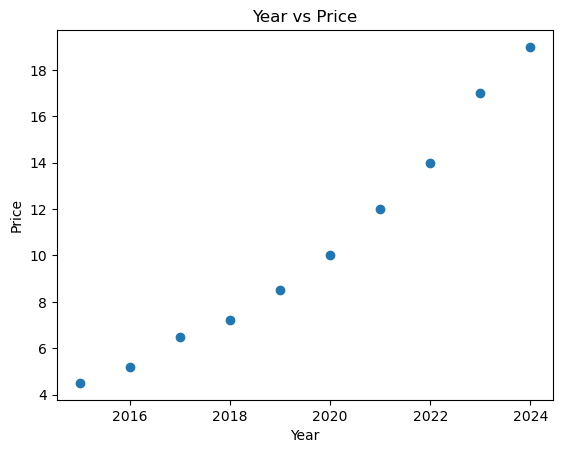

In [2]:
#Visualize Year vs Price
plt.scatter(df[["year"]],df["price"])
plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Year vs Price")
plt.show()

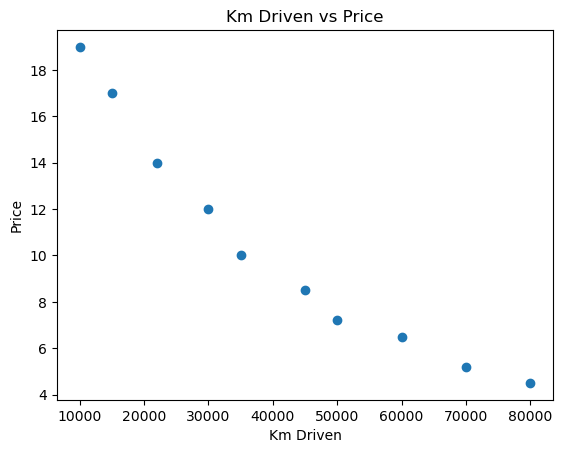

In [5]:
#Visualize Km_driven vs Price
plt.scatter(df[["km_driven"]],df["price"])
plt.xlabel("Km Driven")
plt.ylabel("Price")
plt.title("Km Driven vs Price")
plt.show()

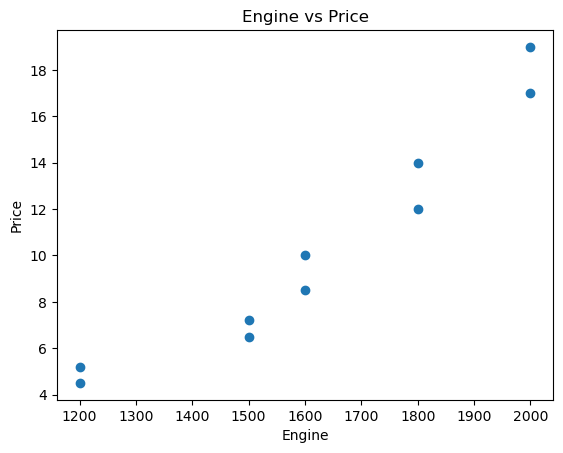

In [4]:
#Visualize Engine vs Price
plt.scatter(df[["engine"]],df["price"])
plt.xlabel("Engine")
plt.ylabel("Price")
plt.title("Engine vs Price")
plt.show()

In [6]:
#Separate the data
X = df[["year" , "km_driven" , "engine"]]
Y = df["price"]

In [10]:
#Split the data
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [11]:
#Train the data
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
#Make a prediction
pred = model.predict(pd.DataFrame({
    "year" : [2021],
    "km_driven" : [25000],
    "engine" : [1800]
}))
print(pred[0])

10.929543746389754


In [13]:
#Test the data
y_pred = model.predict(X_test)
print("Actual",Y_test)
print("Prediction",y_pred)

Actual 8    17.0
1     5.2
Name: price, dtype: float64
Prediction [16.30352614  5.00691382]


In [17]:
#Mean Absolute Error
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(Y_test,y_pred)
print("MAE:",mae)

MAE: 0.4447800219946658


In [18]:
#Mean Squared Error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(Y_test,y_pred)
print("MSE:",mse)

MSE: 0.2611790583253286


In [19]:
#R2 Score
from sklearn.metrics import r2_score
r2 = r2_score(Y_test,y_pred)
print("R2 Score:",r2)

R2 Score: 0.9924970106772385


In [20]:
#Training and testing Performance
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_r2 = r2_score(Y_train , train_pred)
print("Training score",train_r2)
test_r2 = r2_score(Y_test , test_pred)
print("Testing score",test_r2)

Training score 0.9870529727225722
Testing score 0.9924970106772385


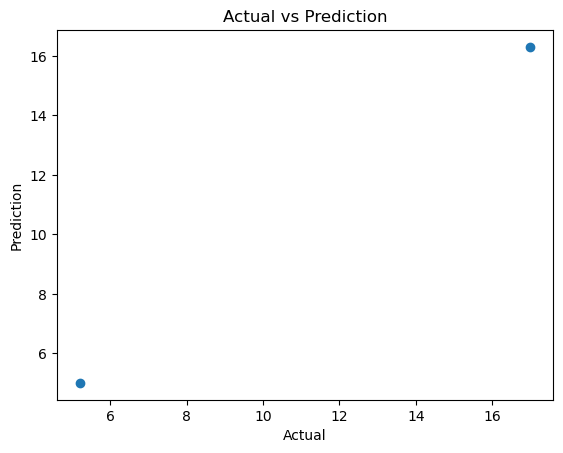

In [21]:
#Visualize the data
plt.scatter(Y_test , y_pred)
plt.xlabel("Actual")
plt.ylabel("Prediction")
plt.title("Actual vs Prediction")
plt.show()